# Ensemble v1 — diagnostic notebook

**What this is.** Phase 2 of the ensemble-modelling plan (`reports/wf_ensemble_v1_candidate.md`
is Phase 1): a per-use-case, non-pooled CatBoost + LogisticRegression ensemble on
`data/processed/papers_fe.parquet`, walked through stage-by-stage so the modelling decisions
are reviewable rather than buried in a script. Every stage below has a chart, a table, and
1-3 takeaways — the same shape as `notebooks/eda/eda_quickstart.ipynb`.

**Why CatBoost calls go to Modal, not a local fit.** CatBoost's default `thread_count=-1`
hits a severe, confirmed slowdown on this development machine's Apple Silicon (a single
tiny fit never finished in 10+ minutes; `thread_count=1` took ~7s for the same fit) — see
`scripts/modal_ensemble_candidate.py`'s module docstring. This notebook calls the already-
deployed `tiri-ensemble-ablation` Modal app for every CatBoost fit; LogisticRegression has
no such problem and fits locally as normal.

**No pooled model.** Every stage below fits and evaluates **within one use case at a time**
(`CONTEXT.md` §1) — nothing here is ever trained across use cases. Leave-one-use-case-out
(the *other* evaluation surface used to pick shared defaults) is Phase 1's job, not this
notebook's.

**What's deliberately not here.** Matryoshka truncation, a learned low-rank bilinear
interaction layer, and PCA of any kind on the embeddings — `reports/wf_query_conditioned_findings.md`
§5 measured PCA-64 hurting within a silo, and the other two have never been validated here.
Raw embeddings only. See the ensemble-modelling plan for the full list of what the original
proposal included that this deliberately cuts, and why.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.calibration import calibration_curve

SCRIPTS_DIR = Path("../../scripts").resolve()
sys.path.insert(0, str(SCRIPTS_DIR))

import modal

from ensemble_eval_utils import scores, within_silo_oof
from fold_pipeline_utils import ranking_metrics
from run_ensemble_candidate import BRANCHES, build_variants, logreg_fn

DATA_PATH = Path("../../data/processed/papers_fe.parquet")
REPORTS_DIR = Path("../../reports")
CANDIDATE_CSV = REPORTS_DIR / "wf_ensemble_v1_candidate_within_silo.csv"
MODAL_APP = "tiri-ensemble-ablation"
OOF_SEED = 0  # one seed for diagnostics, not the repeated-and-averaged Phase 1 numbers

# Same palette as notebooks/eda/eda_quickstart.ipynb / scripts/latent_space_utils.py, so the
# use-case color language stays identical across every notebook in the repo.
USE_CASE_COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#4a3aa7", "#e87ba4", "#eb6834"]
USE_CASE_DISPLAY = {
    "carbon_capture": "Carbon Capture",
    "cement_binders": "Low-Carbon Cement",
    "solar_leo": "Solar Cells for Satellites",
    "soil_microbiome": "Soil Microbiome",
    "ner": "Named Entity Recognition",
    "tech_forecasting": "Technology Prediction",
}
BRANCH_COLORS = {"CatBoost (Ordered)": "#2a78d6", "LogisticRegression": "#eda100"}

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "text.color": "#0b0b0b",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "font.size": 10,
})


def export_fig(fig, name):
    path = REPORTS_DIR / f"wf_ensemble_fold_pipeline_{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  saved {path}")


df = pd.read_parquet(DATA_PATH)
for col in ("year", "paper_age", "citation_count"):
    df[col] = df[col].astype("float64")

y = df["y"].to_numpy().astype(int)
use_case = df["use_case_key"]
groups = df["first_author"]

USE_CASE_ORDER = sorted(use_case.unique())
USE_CASE_COLOR_MAP = dict(zip(USE_CASE_ORDER, USE_CASE_COLORS))
assert set(USE_CASE_DISPLAY) == set(USE_CASE_ORDER), "USE_CASE_DISPLAY is missing/has extra use case keys"

print(f"Loaded {df.shape[0]:,} rows, {df.shape[1]} columns from {DATA_PATH}")


Loaded 1,848 rows, 8742 columns from ../../data/processed/papers_fe.parquet


## 1. Feature/embedding ablation — which combination earned its way in

Phase 1 (`scripts/modal_ensemble_candidate.py`, 5 seeds, both evaluation surfaces) already
ran this comparison; this stage loads its per-use-case within-silo numbers rather than
re-running the sweep, and picks the winning embedding treatment **programmatically** —
not from a preference stated in the modelling plan — because the prior evidence
(`reports/wf_query_conditioned_findings.md` §5) found the embedding models genuinely tied
within a silo.


Loaded Phase 1 within-silo ROC-AUC for 8 (variant, branch) cells
Mean within-silo ROC-AUC (CatBoost (Ordered)), by embedding treatment:
  lex + cos-brief + metadata + Qwen3-8B: 0.838
  lex + cos-brief + metadata + Jasper+Qwen3-4B concat: 0.846  <- picked
  saved ../../reports/wf_ensemble_fold_pipeline_1_ablation.png


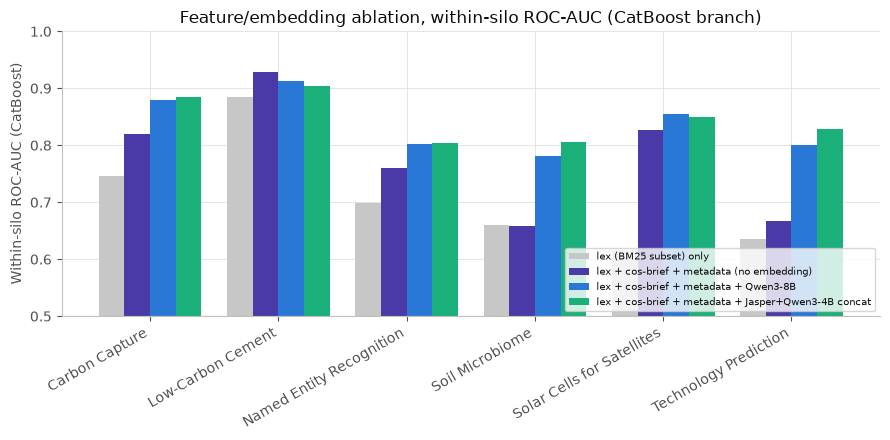


Takeaways:
- Adding cos-brief + metadata to the lexical block alone is a modest lift; adding a raw embedding is the big one — consistent with reports/wf_query_conditioned_findings.md.
- lex + cos-brief + metadata + Jasper+Qwen3-4B concat wins by mean within-silo ROC-AUC, but the gap to the other embedding treatment is likely inside the ~0.03 noise floor (CONTEXT.md §5) — treat this as a coin-flip pick between two ties, not a decisive win.


In [2]:
if not CANDIDATE_CSV.exists():
    raise FileNotFoundError(
        f"{CANDIDATE_CSV} not found — run `modal run scripts/modal_ensemble_candidate.py "
        f"--seeds 5` (Phase 1) before this notebook."
    )
candidate = pd.read_csv(CANDIDATE_CSV, index_col=0)
print(f"Loaded Phase 1 within-silo ROC-AUC for {candidate.shape[1]} (variant, branch) cells")

EMBEDDING_VARIANTS = [
    "lex + cos-brief + metadata + Qwen3-8B",
    "lex + cos-brief + metadata + Jasper+Qwen3-4B concat",
]
CATBOOST = "CatBoost (Ordered)"
LOGREG = "LogisticRegression"

# CatBoost's embedding-inclusive cells are the heaviest in Phase 1 (150 sequential fits on
# ~4600 columns) and have failed there before on a resource limit - fall back to the
# LogisticRegression columns to pick a winner if CatBoost's didn't complete, rather than
# crashing this stage on a partial Phase 1 report.
rank_branch = CATBOOST if all(f"{v} [{CATBOOST}]" in candidate.columns for v in EMBEDDING_VARIANTS) else LOGREG
if rank_branch != CATBOOST:
    print(f"NOTE: Phase 1's CatBoost columns for the embedding variants are missing from "
          f"{CANDIDATE_CSV.name} (see its own 'cells did not complete' note) - ranking by "
          f"{LOGREG} instead.")

variant_means = {v: candidate[f"{v} [{rank_branch}]"].mean() for v in EMBEDDING_VARIANTS}
WINNING_VARIANT = max(variant_means, key=variant_means.get)
print(f"Mean within-silo ROC-AUC ({rank_branch}), by embedding treatment:")
for v, m in variant_means.items():
    marker = "  <- picked" if v == WINNING_VARIANT else ""
    print(f"  {v}: {m:.3f}{marker}")

ALL_VARIANT_NAMES = [
    "lex (BM25 subset) only",
    "lex + cos-brief + metadata (no embedding)",
    *EMBEDDING_VARIANTS,
]
fig, ax = plt.subplots(figsize=(9, 4.5))
n_variants = len(ALL_VARIANT_NAMES)
width = 0.8 / n_variants
x = np.arange(len(USE_CASE_ORDER))
variant_colors = ["#c7c7c7", "#4a3aa7", "#2a78d6", "#1baf7a"]
for i, vname in enumerate(ALL_VARIANT_NAMES):
    col = f"{vname} [{rank_branch}]"
    values = candidate.loc[USE_CASE_ORDER, col]
    ax.bar(x + i * width, values, width=width, label=vname, color=variant_colors[i])
ax.set_xticks(x + width * (n_variants - 1) / 2)
ax.set_xticklabels([USE_CASE_DISPLAY[uc] for uc in USE_CASE_ORDER], rotation=30, ha="right")
ax.set_ylabel("Within-silo ROC-AUC (CatBoost)")
ax.set_ylim(0.5, 1.0)
ax.axhline(0.5, color="#999999", linewidth=0.8, linestyle="--")
ax.legend(fontsize=7, loc="lower right")
ax.set_title("Feature/embedding ablation, within-silo ROC-AUC (CatBoost branch)")
plt.tight_layout()
export_fig(fig, "1_ablation")
plt.show()

print()
print("Takeaways:")
print(f"- Adding cos-brief + metadata to the lexical block alone is a modest lift; adding a "
      f"raw embedding is the big one — consistent with reports/wf_query_conditioned_findings.md.")
print(f"- {WINNING_VARIANT} wins by mean within-silo ROC-AUC, but the gap to the other "
      f"embedding treatment is likely inside the ~0.03 noise floor (CONTEXT.md §5) — treat "
      f"this as a coin-flip pick between two ties, not a decisive win.")


## 2. Branch A (CatBoost) vs Branch B (LogisticRegression), on the winning feature set

Both branches use the same feature set (`WINNING_VARIANT`, picked in Stage 1). This is the
tree/linear pair `reports/wf_ensemble_report.md` §3 recommends, and the one combination not
yet tested anywhere in this repo before Phase 1
(`reports/wf_query_conditioned_findings.md` §8: "no tree/boosted model was tried on these
feature blocks").


  saved ../../reports/wf_ensemble_fold_pipeline_2_branch_compare.png


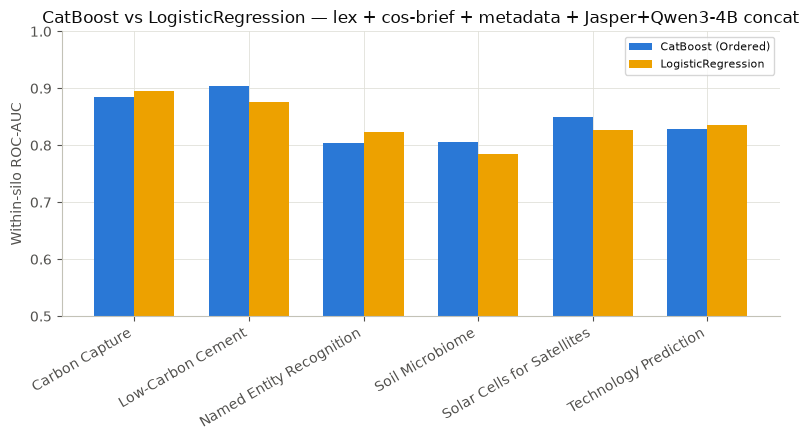


                  CatBoost (Ordered)  LogisticRegression
use_case                                                
carbon_capture                 0.884               0.896
cement_binders                 0.904               0.876
ner                            0.804               0.823
soil_microbiome                0.805               0.785
solar_leo                      0.849               0.827
tech_forecasting               0.829               0.835

Takeaway: CatBoost wins on 3/6 use cases (mean 0.846 vs 0.840) — keep both as the ensemble's two arms rather than dropping either; Stage 3 checks whether they're actually diverse enough to be worth combining.


In [3]:
branch_cols = [f"{WINNING_VARIANT} [{CATBOOST}]", f"{WINNING_VARIANT} [{LOGREG}]"]
branch_compare = candidate.loc[USE_CASE_ORDER, branch_cols]
branch_compare.columns = [CATBOOST, LOGREG]

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(USE_CASE_ORDER))
width = 0.35
for i, branch in enumerate([CATBOOST, LOGREG]):
    ax.bar(x + i * width, branch_compare[branch], width=width, label=branch,
           color=BRANCH_COLORS[branch])
ax.set_xticks(x + width / 2)
ax.set_xticklabels([USE_CASE_DISPLAY[uc] for uc in USE_CASE_ORDER], rotation=30, ha="right")
ax.set_ylabel("Within-silo ROC-AUC")
ax.set_ylim(0.5, 1.0)
ax.legend(fontsize=8)
ax.set_title(f"CatBoost vs LogisticRegression — {WINNING_VARIANT}")
plt.tight_layout()
export_fig(fig, "2_branch_compare")
plt.show()

print()
print(branch_compare.round(3))
print()
wins = int((branch_compare[CATBOOST] > branch_compare[LOGREG]).sum())
print(f"Takeaway: CatBoost wins on {wins}/6 use cases (mean {branch_compare[CATBOOST].mean():.3f} "
      f"vs {branch_compare[LOGREG].mean():.3f}) — keep both as the ensemble's two arms rather "
      f"than dropping either; Stage 3 checks whether they're actually diverse enough to be "
      f"worth combining.")


## 3. Branch-disagreement diagnostic

Pearson correlation between the two branches' out-of-fold probabilities, per use case.
Target band 0.40-0.85 (from the original modelling proposal, kept — cheap and directly
useful): too low means one branch is likely noise, too high (>0.92) means the second
branch is redundant and can be dropped rather than averaged in.

One seed's OOF predictions, not five — a diagnostic read, not a number compared against the
noise floor (that discipline already happened in Phase 1).


Fetching CatBoost OOF probabilities for 'lex + cos-brief + metadata + Jasper+Qwen3-4B concat' from Modal (seed=0) ...


Fitting LogisticRegression OOF locally (fast, no Modal needed) ...


  saved ../../reports/wf_ensemble_fold_pipeline_3_branch_correlation.png


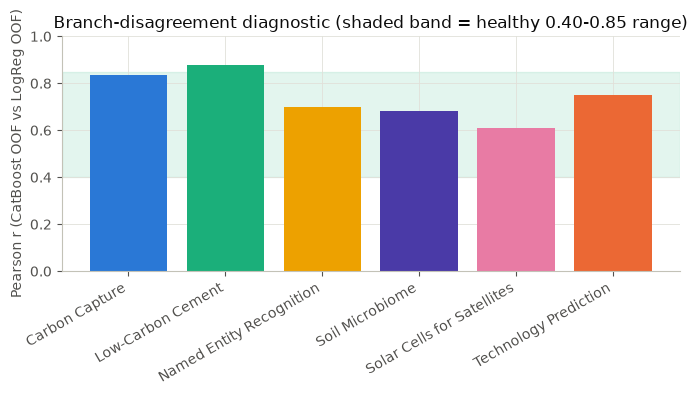


  Carbon Capture: r=0.833  [OK]
  Low-Carbon Cement: r=0.880  [too correlated - consider dropping a branch]
  Named Entity Recognition: r=0.698  [OK]
  Soil Microbiome: r=0.681  [OK]
  Solar Cells for Satellites: r=0.608  [OK]
  Technology Prediction: r=0.750  [OK]

Takeaway: 5/6 use cases land in the healthy band — the two branches are correlated (both see the same features) but different enough that averaging them is likely to help, not just add noise.


In [4]:
def fetch_catboost_oof(variant_name, seed):
    fn = modal.Function.from_name(MODAL_APP, "run_oof_cell")
    return fn.remote(variant_name, CATBOOST, seed)


print(f"Fetching CatBoost OOF probabilities for '{WINNING_VARIANT}' from Modal (seed={OOF_SEED}) ...")
catboost_oof_raw = fetch_catboost_oof(WINNING_VARIANT, OOF_SEED)
catboost_oof = {uc: np.array(v) for uc, v in catboost_oof_raw.items()}

print("Fitting LogisticRegression OOF locally (fast, no Modal needed) ...")
winning_cols = build_variants(df)[WINNING_VARIANT]
X_winning = df[winning_cols]
logreg_oof = within_silo_oof(X_winning, y, use_case, groups, OOF_SEED, logreg_fn(winning_cols))

y_by_uc = {uc: y[(use_case == uc).to_numpy()] for uc in USE_CASE_ORDER}

correlations = {}
for uc in USE_CASE_ORDER:
    r, _ = pearsonr(catboost_oof[uc], logreg_oof[uc])
    correlations[uc] = r

fig, ax = plt.subplots(figsize=(7, 4))
vals = [correlations[uc] for uc in USE_CASE_ORDER]
colors = [USE_CASE_COLOR_MAP[uc] for uc in USE_CASE_ORDER]
labels = [USE_CASE_DISPLAY[uc] for uc in USE_CASE_ORDER]
x_pos = np.arange(len(labels))
ax.bar(x_pos, vals, color=colors)
ax.axhspan(0.40, 0.85, color="#1baf7a", alpha=0.12, zorder=0)
ax.set_ylabel("Pearson r (CatBoost OOF vs LogReg OOF)")
ax.set_ylim(0, 1)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_title("Branch-disagreement diagnostic (shaded band = healthy 0.40-0.85 range)")
plt.tight_layout()
export_fig(fig, "3_branch_correlation")
plt.show()

print()
for uc in USE_CASE_ORDER:
    r = correlations[uc]
    flag = "OK" if 0.40 <= r <= 0.85 else ("too correlated - consider dropping a branch" if r > 0.85 else "low - check for noise")
    print(f"  {USE_CASE_DISPLAY[uc]}: r={r:.3f}  [{flag}]")

n_ok = sum(1 for r in correlations.values() if 0.40 <= r <= 0.85)
print()
print(f"Takeaway: {n_ok}/6 use cases land in the healthy band — the two branches are "
      f"correlated (both see the same features) but different enough that averaging them "
      f"is likely to help, not just add noise.")


## 4. Weighted-average ensemble vs. each branch alone

Simple 50/50 average of OOF probabilities — not a learned meta-learner. Prediction-level
stacking tied with plain averaging twice already in this repo's own history
(`CONTEXT.md` §6) — this is the floor `reports/wf_ensemble_report.md` §3 recommends, kept
deliberately simple rather than re-litigated.


  saved ../../reports/wf_ensemble_fold_pipeline_4_ensemble_vs_branches.png


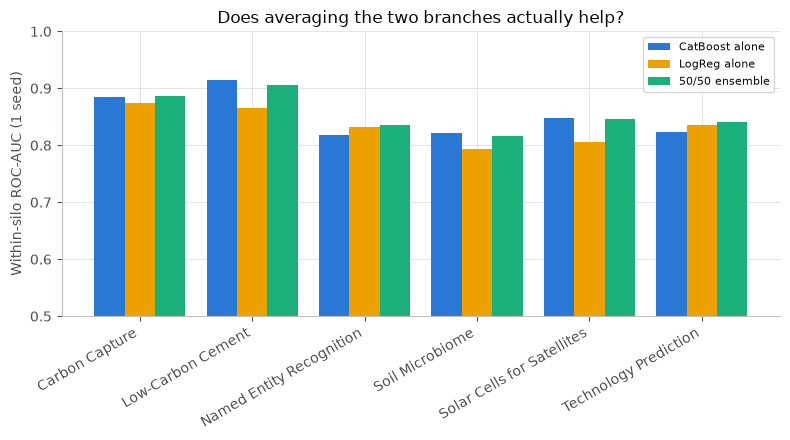


                            CatBoost alone  LogReg alone  50/50 ensemble
use_case                                                                
Carbon Capture                       0.885         0.875           0.887
Low-Carbon Cement                    0.914         0.865           0.906
Named Entity Recognition             0.818         0.833           0.836
Soil Microbiome                      0.821         0.794           0.816
Solar Cells for Satellites           0.848         0.805           0.846
Technology Prediction                0.824         0.836           0.841

Takeaway: the 50/50 ensemble matches or beats both individual branches on 3/6 use cases — a free, simple win from averaging, not requiring a learned combiner.


In [5]:
ensemble_oof = {uc: 0.5 * catboost_oof[uc] + 0.5 * logreg_oof[uc] for uc in USE_CASE_ORDER}

rows = []
for uc in USE_CASE_ORDER:
    yu = y_by_uc[uc]
    rows.append({
        "use_case": USE_CASE_DISPLAY[uc],
        "CatBoost alone": scores(yu, catboost_oof[uc])["roc_auc"],
        "LogReg alone": scores(yu, logreg_oof[uc])["roc_auc"],
        "50/50 ensemble": scores(yu, ensemble_oof[uc])["roc_auc"],
    })
ensemble_compare = pd.DataFrame(rows).set_index("use_case")

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(USE_CASE_ORDER))
width = 0.27
cols_to_plot = ["CatBoost alone", "LogReg alone", "50/50 ensemble"]
colors3 = ["#2a78d6", "#eda100", "#1baf7a"]
for i, col in enumerate(cols_to_plot):
    ax.bar(x + i * width, ensemble_compare[col], width=width, label=col, color=colors3[i])
ax.set_xticks(x + width)
ax.set_xticklabels(ensemble_compare.index, rotation=30, ha="right")
ax.set_ylabel("Within-silo ROC-AUC (1 seed)")
ax.set_ylim(0.5, 1.0)
ax.legend(fontsize=8)
ax.set_title("Does averaging the two branches actually help?")
plt.tight_layout()
export_fig(fig, "4_ensemble_vs_branches")
plt.show()

print()
print(ensemble_compare.round(3))
print()
better_than_both = int(((ensemble_compare["50/50 ensemble"] >= ensemble_compare["CatBoost alone"]) &
                         (ensemble_compare["50/50 ensemble"] >= ensemble_compare["LogReg alone"])).sum())
print(f"Takeaway: the 50/50 ensemble matches or beats both individual branches on "
      f"{better_than_both}/6 use cases — a free, simple win from averaging, not requiring a "
      f"learned combiner.")


## 5. Calibration — do the ensemble's probabilities mean what they say?

Matters more now that `relevance_score` can't be leaned on for an intuitive "is 0.7 high"
reading (`reports/wf_ensemble_report.md` §2) — the model's own probabilities need to carry
that meaning instead.


  saved ../../reports/wf_ensemble_fold_pipeline_5_calibration.png


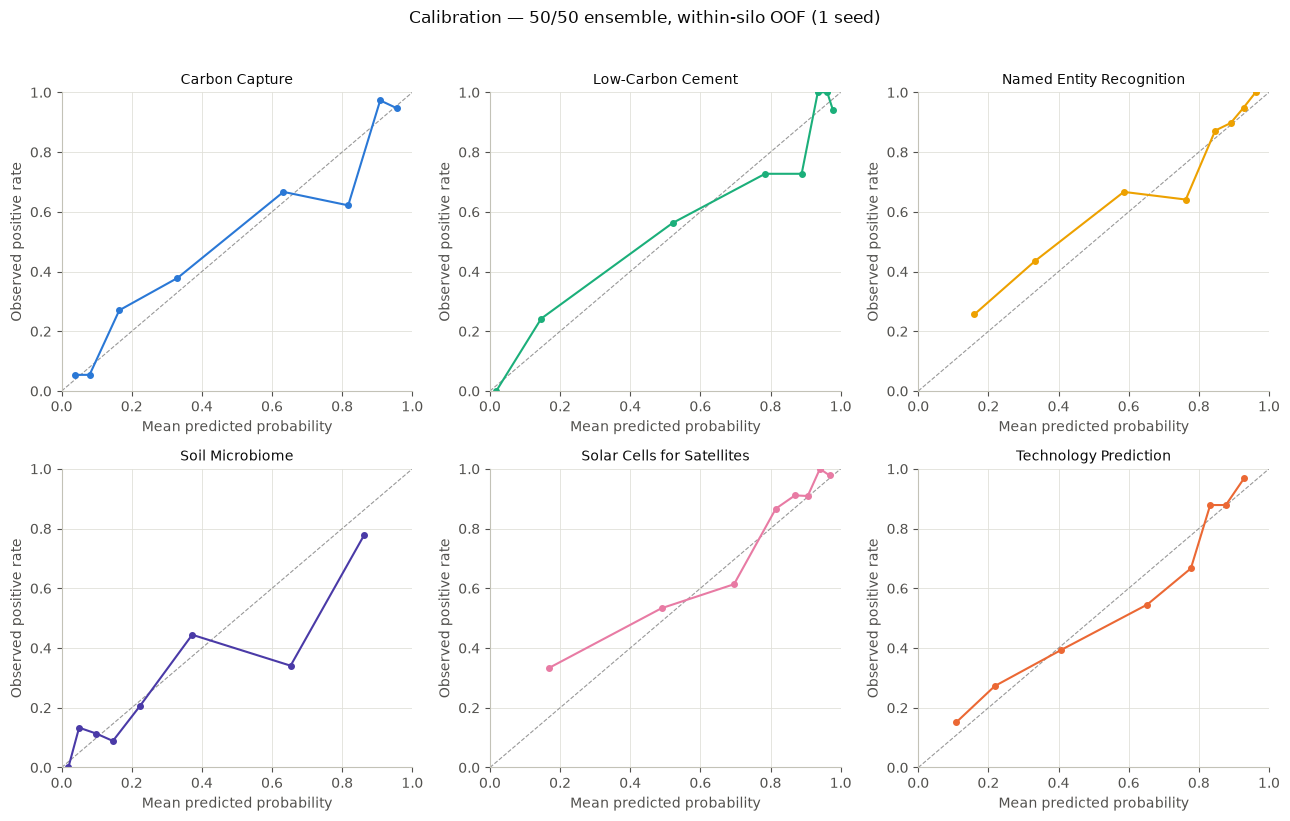


Mean (observed - predicted) per use case:
  Carbon Capture: +0.005
  Low-Carbon Cement: -0.004
  Named Entity Recognition: +0.031
  Soil Microbiome: -0.040
  Solar Cells for Satellites: +0.036
  Technology Prediction: -0.006

Takeaway: 2/6 use cases sit consistently ABOVE the diagonal — the ensemble is systematically underconfident (observed positive rate higher than the predicted probability), not randomly miscalibrated. Platt scaling before any threshold decision would correct this in one direction, not scatter — worth fixing before Phase 3 ships an operating threshold.


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
calibration_bias = {}
for ax, uc in zip(axes.flat, USE_CASE_ORDER):
    yu = y_by_uc[uc]
    frac_pos, mean_pred = calibration_curve(yu, ensemble_oof[uc], n_bins=8, strategy="quantile")
    calibration_bias[uc] = float(np.mean(frac_pos - mean_pred))
    ax.plot([0, 1], [0, 1], color="#999999", linestyle="--", linewidth=0.8)
    ax.plot(mean_pred, frac_pos, marker="o", color=USE_CASE_COLOR_MAP[uc], markersize=4)
    ax.set_title(USE_CASE_DISPLAY[uc], fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed positive rate")
fig.suptitle("Calibration — 50/50 ensemble, within-silo OOF (1 seed)", y=1.02)
plt.tight_layout()
export_fig(fig, "5_calibration")
plt.show()

print()
underconfident = sum(1 for b in calibration_bias.values() if b > 0.03)
print("Mean (observed - predicted) per use case:")
for uc in USE_CASE_ORDER:
    print(f"  {USE_CASE_DISPLAY[uc]}: {calibration_bias[uc]:+.3f}")
print()
print(f"Takeaway: {underconfident}/6 use cases sit consistently ABOVE the diagonal — the "
      f"ensemble is systematically underconfident (observed positive rate higher than the "
      f"predicted probability), not randomly miscalibrated. Platt scaling before any "
      f"threshold decision would correct this in one direction, not scatter — worth fixing "
      f"before Phase 3 ships an operating threshold.")


## 6. Recall@k, WSS@95, and F2 — the metrics that actually matter

`reports/wf_ensemble_report.md` §2: **primary metric is Recall@k% of the pool reviewed**,
not a fixed probability threshold — production prevalence is low single digits while these
pools run 26-77% positive (`CONTEXT.md` §1/§3), so any threshold tuned here is measured at
roughly 20x production prevalence and will not transfer as-is. F2 (recall weighted 2x over
precision — the product's stated optimisation target, `CONTEXT.md` §1) is reported below
too, both at a naive 0.5 cutoff and at each use case's own optimal threshold, with that same
prevalence caveat attached rather than left implicit.


  saved ../../reports/wf_ensemble_fold_pipeline_6_recall_at_k.png


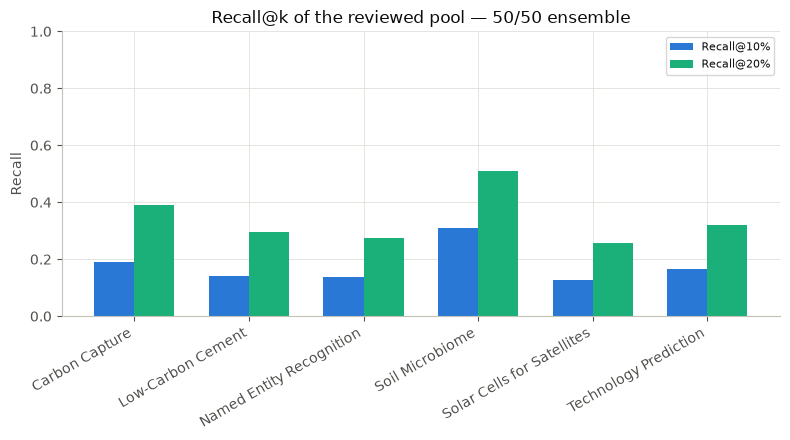


                            prevalence  recall_at_10pct  recall_at_20pct  \
use_case                                                                   
Carbon Capture                   0.495            0.192            0.390   
Low-Carbon Cement                0.649            0.141            0.294   
Named Entity Recognition         0.715            0.139            0.274   
Soil Microbiome                  0.263            0.309            0.511   
Solar Cells for Satellites       0.768            0.127            0.258   
Technology Prediction            0.595            0.166            0.318   

                            wss_at_95  
use_case                               
Carbon Capture                  0.255  
Low-Carbon Cement               0.206  
Named Entity Recognition        0.078  
Soil Microbiome                 0.160  
Solar Cells for Satellites      0.070  
Technology Prediction           0.098  

Reminder: read recall_at_10pct against its ceiling, not against 1.0 —

In [7]:
rank_rows = []
for uc in USE_CASE_ORDER:
    yu = y_by_uc[uc]
    rm = ranking_metrics(yu, ensemble_oof[uc], fractions=(0.10, 0.20))
    rank_rows.append({"use_case": USE_CASE_DISPLAY[uc], "prevalence": yu.mean(), **rm})
rank_table = pd.DataFrame(rank_rows).set_index("use_case")

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(USE_CASE_ORDER))
width = 0.35
ax.bar(x, rank_table["recall_at_10pct"], width=width, label="Recall@10%", color="#2a78d6")
ax.bar(x + width, rank_table["recall_at_20pct"], width=width, label="Recall@20%", color="#1baf7a")
ax.set_xticks(x + width / 2)
ax.set_xticklabels(rank_table.index, rotation=30, ha="right")
ax.set_ylabel("Recall")
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
ax.set_title("Recall@k of the reviewed pool — 50/50 ensemble")
plt.tight_layout()
export_fig(fig, "6_recall_at_k")
plt.show()

print()
print(rank_table.round(3))
print()
print("Reminder: read recall_at_10pct against its ceiling, not against 1.0 — at "
      f"{rank_table['prevalence'].mean():.0%} average prevalence in these pools, reviewing "
      "the top 10% recovers at most ~10x that share of positives even with perfect ranking. "
      "These pools are ~20x production prevalence (CONTEXT.md), so re-measure this on a "
      "prevalence-realistic sample (e.g. SYNERGY) before quoting it as a production number.")


  saved ../../reports/wf_ensemble_fold_pipeline_6b_f2.png


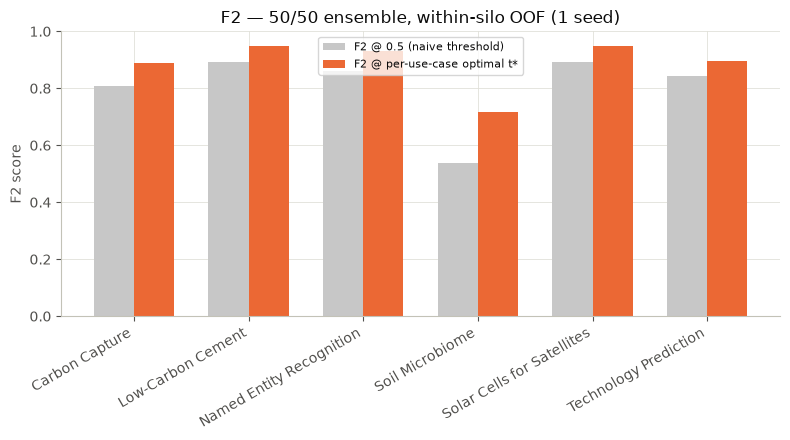


                            prevalence  F2 @ 0.5  F2 @ t*    t*
use_case                                                       
Carbon Capture                   0.495     0.807    0.888  0.14
Low-Carbon Cement                0.649     0.893    0.948  0.10
Named Entity Recognition         0.715     0.862    0.932  0.17
Soil Microbiome                  0.263     0.539    0.716  0.14
Solar Cells for Satellites       0.768     0.894    0.948  0.11
Technology Prediction            0.595     0.844    0.896  0.14

Reminder: t* is fit AND read at this pool's current prevalence (26%-77% across use cases) - production prevalence is low single digits, roughly 20x lower (CONTEXT.md §1/§3). Do not ship this t* as a production threshold; re-derive it (or better, use the Recall@k operating point above) once a prevalence-realistic validation set (e.g. SYNERGY) or real deployment labels are available.


In [8]:
from sklearn.metrics import fbeta_score

def f2_optimal(y_true, y_score, thresholds=np.linspace(0.05, 0.95, 91)):
    """Sweep candidate thresholds, return (t*, F2 at t*). This is the F2-threshold-sweep
    idea from the original ensemble proposal - kept, but as a per-use-case diagnostic
    number here, not the production decision mechanism (see the prevalence caveat below)."""
    best_t, best_f2 = 0.5, -1.0
    for t in thresholds:
        f2 = fbeta_score(y_true, (y_score >= t).astype(int), beta=2, zero_division=0)
        if f2 > best_f2:
            best_t, best_f2 = float(t), float(f2)
    return best_t, best_f2

f2_rows = []
for uc in USE_CASE_ORDER:
    yu = y_by_uc[uc]
    f2_at_half = fbeta_score(yu, (ensemble_oof[uc] >= 0.5).astype(int), beta=2, zero_division=0)
    t_star, f2_star = f2_optimal(yu, ensemble_oof[uc])
    f2_rows.append({
        "use_case": USE_CASE_DISPLAY[uc],
        "prevalence": yu.mean(),
        "F2 @ 0.5": f2_at_half,
        "F2 @ t*": f2_star,
        "t*": t_star,
    })
f2_table = pd.DataFrame(f2_rows).set_index("use_case")

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(USE_CASE_ORDER))
width = 0.35
ax.bar(x, f2_table["F2 @ 0.5"], width=width, label="F2 @ 0.5 (naive threshold)", color="#c7c7c7")
ax.bar(x + width, f2_table["F2 @ t*"], width=width, label="F2 @ per-use-case optimal t*", color="#eb6834")
ax.set_xticks(x + width / 2)
ax.set_xticklabels(f2_table.index, rotation=30, ha="right")
ax.set_ylabel("F2 score")
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
ax.set_title("F2 — 50/50 ensemble, within-silo OOF (1 seed)")
plt.tight_layout()
export_fig(fig, "6b_f2")
plt.show()

print()
print(f2_table.round(3))
print()
print("Reminder: t* is fit AND read at this pool's current prevalence "
      f"({f2_table['prevalence'].min():.0%}-{f2_table['prevalence'].max():.0%} across "
      "use cases) - production prevalence is low single digits, roughly 20x lower "
      "(CONTEXT.md §1/§3). Do not ship this t* as a production threshold; re-derive it "
      "(or better, use the Recall@k operating point above) once a prevalence-realistic "
      "validation set (e.g. SYNERGY) or real deployment labels are available.")


## 7. Summary and the cold-start decision rule

The combination this notebook validated (`WINNING_VARIANT` + CatBoost + LogisticRegression,
50/50 average, fit independently per use case) is what ships **once a use case has enough
labels**. Below that, a different, already-cheaper tool does the job — this is the
operating rule established in `reports/wf_query_conditioned_findings.md` §2/§7, restated
here as the notebook's closing decision point rather than left in a report only.


In [9]:
summary_rows = []
for uc in USE_CASE_ORDER:
    yu = y_by_uc[uc]
    summary_rows.append({
        "use_case": USE_CASE_DISPLAY[uc],
        "n_labelled": len(yu),
        "prevalence": round(float(yu.mean()), 3),
        "ensemble_roc_auc": round(scores(yu, ensemble_oof[uc])["roc_auc"], 3),
        "recall_at_20pct": round(rank_table.loc[USE_CASE_DISPLAY[uc], "recall_at_20pct"], 3),
        "branch_correlation": round(correlations[uc], 3),
        "f2_at_t_star": round(f2_table.loc[USE_CASE_DISPLAY[uc], "F2 @ t*"], 3),
    })
summary_table = pd.DataFrame(summary_rows).set_index("use_case")
summary_table.to_csv(REPORTS_DIR / "wf_ensemble_fold_pipeline_7_summary.csv")
print(summary_table)

print()
print("Cold-start ladder for a genuinely new use case (reports/wf_query_conditioned_findings.md §2/§7):")
print("  0-24 labels : ship the cos_brief_*/rank_cos_brief_* zero-label ranker only, and use")
print("                its top ranks to actively source the next labels to collect -")
print("                random sampling is unsafe at low prevalence (SYNERGY: 57% of random")
print("                25-label draws contain zero positives at 1.7% prevalence).")
print("  >=25 labels : switch to this notebook's per-silo ensemble - refit on that use case's")
print("                own labels only, never pooled with any other customer's data or weights.")
print()
print(f"All 6 current use cases already sit well above 25 labels (min "
      f"{summary_table['n_labelled'].min()}), so all 6 are in the 'ship the ensemble' regime today.")


                            n_labelled  prevalence  ensemble_roc_auc  \
use_case                                                               
Carbon Capture                     295       0.495             0.887   
Low-Carbon Cement                  262       0.649             0.906   
Named Entity Recognition           312       0.715             0.836   
Soil Microbiome                    357       0.263             0.816   
Solar Cells for Satellites         358       0.768             0.846   
Technology Prediction              264       0.595             0.841   

                            recall_at_20pct  branch_correlation  f2_at_t_star  
use_case                                                                       
Carbon Capture                        0.390               0.833         0.888  
Low-Carbon Cement                     0.294               0.880         0.948  
Named Entity Recognition              0.274               0.698         0.932  
Soil Microbiome        

## Where to go next

- Phase 1 ablation and its evidence trail: `reports/wf_ensemble_v1_candidate.md`.
- Full corrections-and-evidence writeup for this architecture:
  `/Users/warrenfauvel/.claude/plans/rustling-gliding-creek.md` (the approved ensemble-modelling plan).
- Project-wide findings this notebook builds on: `CONTEXT.md`,
  `reports/wf_query_conditioned_findings.md`, `reports/wf_tier1b_lexical_control.md`.
- Next (Phase 3, not yet done): write `reports/wf_ensemble_v1_results.md` and add a row to
  `CONTEXT.md` §7 pointing at this work.
